<a href="https://colab.research.google.com/github/Melsaftawy98/Image_Segmentation_With_Pytorch/blob/main/Image_Segmentation_Deep_Learning_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 : Set up colab gpu runtime environment

In [ ]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-vy9w9au5
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-vy9w9au5
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Download Dataset

original author of the dataset :
https://github.com/VikramShenoy97/Human-Segmentation-Dataset


In [ ]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

Cloning into 'Human-Segmentation-Dataset-master'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (592/592), done.
remote: Compressing objects: 100% (591/591), done.
remote: Total 592 (delta 3), reused 588 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (592/592), 13.60 MiB | 3.47 MiB/s, done.
Resolving deltas: 100% (3/3), done.


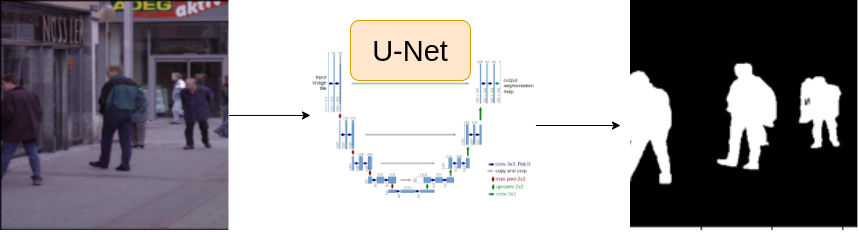

# Some Common Imports

In [ ]:
import sys
sys.path.append('/content/Human-Segmentation-Dataset-master')

In [ ]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

# Task : 2 Setup Configurations

In [ ]:

#setting up the path
csv_file = '/content/Human-Segmentation-Dataset-master/train.csv'
data_dir = '/content/'

device = 'cuda' #since we are using GPU
epochs = 25
LR = 0.003
IMG_SIZE = 320 #fix all images in the same width and height
BATCH_SIZE = 16

ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [ ]:
#plotting the images
df = pd.read_csv(csv_file)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [ ]:
#Extracting one row of image
row = df.iloc[0]
image_path = row.images
mask_path = row.masks

#reading the image using openCV
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #convert the image to RGB

#reading the mask
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0 # for grayscale


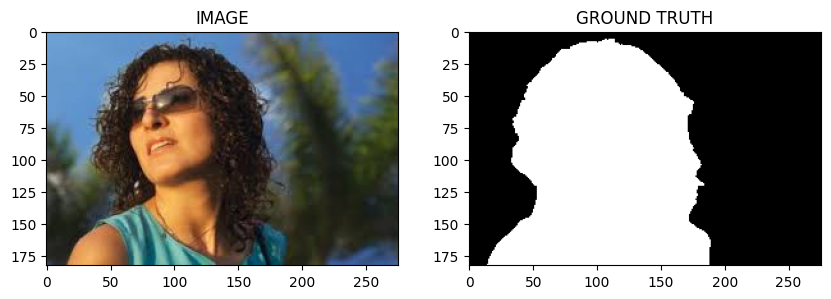

In [ ]:
#visualization
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

#showing the image
ax1.set_title('IMAGE')
ax1.imshow(image)

#showing the mask
ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [ ]:
#split the data into training and testing set
train_df, test_df = train_test_split(df,test_size=0.2,random_state=42)

# Task 3 : Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [ ]:
import albumentations as A

In [ ]:
#transforming the training images
def get_train_augs():
  train_transform = A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE), #resize
      A.HorizontalFlip(p=0.5), #augmentaion
      A.VerticalFlip(p=0.5)], is_check_shapes=False) #augmentation
  return train_transform

#transforming test images
def get_test_augs():
  test_transform = A.Compose([
      A.Resize(IMG_SIZE,IMG_SIZE)], is_check_shapes=False)
  return test_transform

# Task 4 : Create Custom Dataset

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class SegmentationDataset(Dataset):
  def __init__(self,df,augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) #mask will have a shape of (height, width, grayscale image channel)
    mask =np.expand_dims(mask, axis=-1) #mask will have a shape of (height, width, 1)

    if self.augmentations: #if augmentation is true
      data = self.augmentations(image= image, mask=mask) #return images and masks in dictionary format
      image = data['image']
      mask = data['mask']

    #(h,w,c)->(c,h,w)
    image = np.transpose(image, (2,0,1)).astype(np.float32)
    mask = np.transpose(mask, (2,0,1)).astype(np.float32)

    #convert from numpy to tensor
    image = torch.Tensor(image)/255.0 #maintain ranges between 0 and 1
    mask = torch.round(torch.Tensor(mask)/255.0) #maintain ranges between 0 and 1 and also round the numbers

    return image, mask

In [ ]:
#create train and test dataset
trainset = SegmentationDataset(train_df,get_train_augs())
testset = SegmentationDataset(test_df,get_test_augs())

In [ ]:
print(f"Size of Train set : {len(trainset)}")
print(f"Size of Test set : {len(testset)}")

Size of Train set : 232
Size of Test set : 58


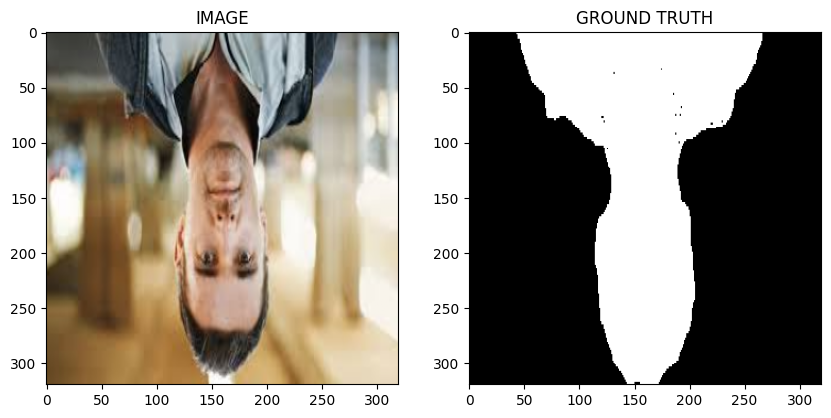

In [ ]:
#plotting the images
idx = 32
image, mask = trainset[idx]
helper.show_image(image,mask)

# Task 5 : Load dataset into batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
trainLoader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testLoader = DataLoader(testset, batch_size = BATCH_SIZE)

In [ ]:
print(f"Total number of batches in the Train loader: {len(trainLoader)}") #total number of batches (train loader) = size of train set / batch size
print(f"Total number of batches in the Test loader: {len(testLoader)}") #total number of batches (test loader) = size of test set / batch size

Total number of batches in the Train loader: 15
Total number of batches in the Test loader: 4


In [ ]:
for image, mask in trainLoader:
  break

print(f"batch image shape: {image.shape}")
print(f"batch mask shape: {mask.shape}")

batch image shape: torch.Size([16, 3, 320, 320])
batch mask shape: torch.Size([16, 1, 320, 320])


# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [ ]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [ ]:
class SegmentationModel(nn.Module):

  def __init__(self):
    super(SegmentationModel, self).__init__()

    self.arc = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels =3 ,
        classes =1,
        activation = None)

  def forward(self,images,masks=None):
    logits = self.arc(images)

    if masks !=None:
      loss1 = DiceLoss(mode='binary')(logits,masks)
      loss2 = nn.BCEWithLogitsLoss()(logits,masks)
      return logits, loss1+loss2

    return logits

In [ ]:
model = SegmentationModel()
model.to(device);

# Task 7 : Create Train and Validation Function

In [ ]:
def train_fn(model, data_loader, optimizer):
  #initialization
  model.train()
  total_loss = 0.0

  for images, masks in tqdm(data_loader):
    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad() #make sure the gradients are 0
    logits, loss = model(images,masks) #forward pass
    loss.backward() #backward pass
    optimizer.step() #update the weights

    total_loss += loss.item()

  return total_loss/len(data_loader) #return average loss

In [ ]:
def val_fn(model, data_loader):
  #initialization
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader):
      images = images.to(device)
      masks = masks.to(device)

      logits, loss = model(images,masks) #forward pass

      total_loss += loss.item()

  return total_loss/len(data_loader) #return average loss

# Task 8 : Train Model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [ ]:
best_valid_loss = np.inf

for i in range(epochs):

  train_loss = train_fn(model, trainLoader, optimizer)
  valid_loss = val_fn(model, testLoader)

  #save the best validation model on the basis of validation loss
  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    print("MODEL SAVED")
    best_valid_loss = valid_loss

  print(f"Epoch : {i+1} Train_loss: {train_loss} Valid_loss: {valid_loss}")


100%|██████████| 4/4 [00:00<00:00,  4.85it/s]


MODEL SAVED
Epoch : 1 Train_loss: 0.7414906601111094 Valid_loss: 0.7607323676347733


100%|██████████| 4/4 [00:00<00:00,  5.82it/s]


MODEL SAVED
Epoch : 2 Train_loss: 0.36727426846822103 Valid_loss: 0.36379410326480865


100%|██████████| 4/4 [00:00<00:00,  5.84it/s]


...

Epoch : 23 Train_loss: 0.09690120418866476 Valid_loss: 0.1936487965285778


100%|██████████| 4/4 [00:00<00:00,  4.73it/s]


Epoch : 24 Train_loss: 0.09724024857083956 Valid_loss: 0.16271022520959377


100%|██████████| 4/4 [00:00<00:00,  6.01it/s]

Epoch : 25 Train_loss: 0.10847852478424708 Valid_loss: 0.21562302485108376


# Task 9 : Inference

In [ ]:
idx = 2
model.load_state_dict(torch.load('best_model.pt'))
image,mask = testset[idx]
logits_mask = model(image.to(device).unsqueeze(0)) #(c,h,w) -> (1,c,h,w)
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5) * 1.0

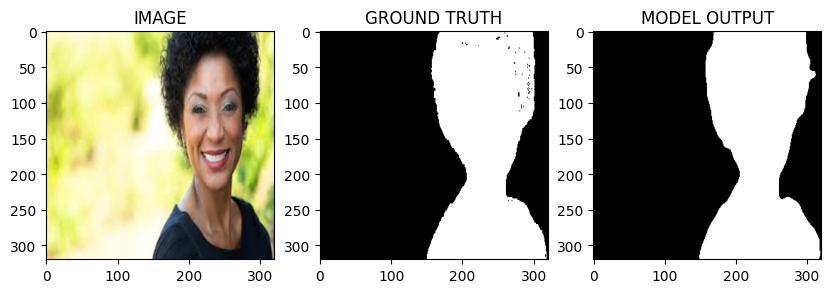

In [ ]:
helper.show_image(image,mask,pred_mask.detach().cpu().squeeze(0))

# For updates about upcoming and current guided projects follow me on...

Twitter : @parth_AI

Linkedin : www.linkedin.com/in/pdhameliya